# Manufacturing Machine Learning Project

## 프로젝트 개요

이 프로젝트는 정형 제조 데이터를 기반으로 설비의 고장 여부를 예측하는 머신러닝 프로젝트이다.

AI4I 2020 Predictive Maintenance Dataset을 기반으로 머신러닝 모델을 학습하여 설비의 정상/고장 여부를 예측하는 이진분류 모델을 구축한다.

## 모델링 목표

- 제조 설비의 고장 여부를 예측한다.
- `failure` 컬럼을 target으로 사용한다.
- 정상 데이터와 고장 데이터의 불균형을 고려한다.
- Logistic Regression을 baseline 모델로 학습한다.
- RandomForest 모델을 학습하고 baseline과 비교한다.
- Accuracy, Precision, Recall, F1-score, ROC-AUC를 사용하여 모델을 평가한다.
- Feature Importance를 통해 주요 원인 feature를 해석한다.

# 0. 환경 준비

데이터 분석과 머신러닝 모델 학습에 필요한 라이브러리를 불러온다.

또한 프로젝트 내에서 사용할 주요 경로를 설정한다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
FIGURE_DIR = BASE_DIR / "figures"
REPORT_DIR = BASE_DIR / "reports"
MODEL_DIR = BASE_DIR / "models"

FIGURE_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

# 1. 데이터 불러오기

AI4I 2020 Predictive Maintenance Dataset을 불러온다.

데이터 파일은 프로젝트의 `data` 폴더에 저장되어 있으며, 파일명은 `ai4i2020.csv`로 설정한다.

In [4]:
df = pd.read_csv(DATA_DIR / "ai4i2020.csv")

print("데이터 크기:", df.shape)
df.head()

데이터 크기: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 데이터 불러오기 결과

AI4I 2020 Predictive Maintenance Dataset을 정상적으로 불러왔다.

데이터는 제조 설비의 센서값, 제품 유형, 고장 여부, 세부 고장 유형 정보를 포함하고 있다.

이후 단계에서는 고장 여부를 나타내는 `Machine failure` 컬럼을 이진분류 target으로 사용한다.

# 2. 데이터 구조 확인

모델링을 진행하기 전에 데이터의 컬럼, 데이터 타입, 기초 통계량, 결측치 여부를 확인한다.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [7]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [8]:
missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_ratio": df.isnull().mean() * 100
})

missing_report

,missing_count,missing_ratio
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


## 데이터 구조 확인 결과

데이터의 전체 행과 컬럼 수, 각 컬럼의 데이터 타입을 확인하였다.

결측치 확인 결과, 모든 컬럼에서 결측치 개수는 0개이며 결측치 비율도 0.0%로 나타났다.  
따라서 이번 모델링 과정에서는 별도의 결측치 대체 또는 제거 작업이 필요하지 않다.

이 데이터는 제품 유형, 온도, 회전 속도, 토크, 공구 마모 시간 등의 feature와 고장 여부 label을 포함하고 있으므로 이진분류 모델링에 사용할 수 있다.

# 3. 컬럼명 정리

모델링 과정에서 컬럼명을 쉽게 사용하기 위해 컬럼명을 간단한 형태로 변경한다.

공백, 대괄호, 단위가 포함된 컬럼명을 snake_case 형식으로 정리한다.

In [9]:
df = df.rename(columns={
    "UDI": "udi",
    "Product ID": "product_id",
    "Type": "type",
    "Air temperature [K]": "air_temp",
    "Process temperature [K]": "process_temp",
    "Rotational speed [rpm]": "rot_speed",
    "Torque [Nm]": "torque",
    "Tool wear [min]": "tool_wear",
    "Machine failure": "failure"
})

sensor_cols = [
    "air_temp",
    "process_temp",
    "rot_speed",
    "torque",
    "tool_wear"
]

df.head()

,udi,product_id,type,air_temp,process_temp,rot_speed,torque,tool_wear,failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [10]:
df.columns

Index(['udi', 'product_id', 'type', 'air_temp', 'process_temp', 'rot_speed',
       'torque', 'tool_wear', 'failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

## 컬럼명 정리 결과

기존 컬럼명은 공백과 단위가 포함되어 있어 코드 작성 시 불편함이 있었다.

따라서 주요 컬럼명을 snake_case 형태로 변경하였다.

이후 모델링에서는 `air_temp`, `process_temp`, `rot_speed`, `torque`, `tool_wear`를 주요 센서 feature로 사용하고, `failure`를 target으로 사용한다.

# 4. 이진분류 문제 정의

이번 프로젝트는 제조 설비의 고장 여부를 예측하는 이진분류 문제이다.

Target 변수는 `failure` 컬럼이다.

- `failure = 0`: 정상
- `failure = 1`: 고장

모델링 전에 target의 분포를 확인하여 데이터 불균형 여부를 점검한다.

In [11]:
failure_count = df["failure"].value_counts()
failure_ratio = df["failure"].value_counts(normalize=True) * 100

print("Failure count")
print(failure_count)

print("\nFailure ratio")
print(failure_ratio)

print(f"\n전체 고장률: {df['failure'].mean() * 100:.2f}%")

Failure count
failure
0    9661
1     339
Name: count, dtype: int64

Failure ratio
failure
0    96.61
1     3.39
Name: proportion, dtype: float64

전체 고장률: 3.39%


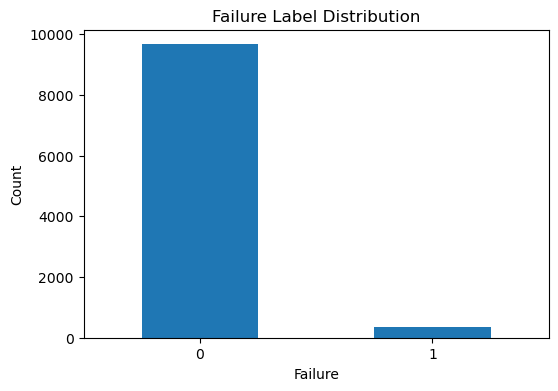

In [12]:
plt.figure(figsize=(6, 4))
failure_count.sort_index().plot(kind="bar")

plt.xlabel("Failure")
plt.ylabel("Count")
plt.title("Failure Label Distribution")
plt.xticks(rotation=0)

plt.savefig(FIGURE_DIR / "failure_label_distribution.png", bbox_inches="tight")
plt.show()

## 이진분류 target 분포 확인 결과

`failure` 컬럼의 분포를 확인한 결과, 정상 데이터가 대부분을 차지하고 고장 데이터는 상대적으로 적게 나타났다.

따라서 이 데이터는 클래스 불균형 문제가 존재한다.

이후 모델 평가에서는 단순 Accuracy만 사용하지 않고, Precision, Recall, F1-score, ROC-AUC를 함께 사용해야 한다.

특히 제조 설비 고장 예측에서는 실제 고장을 정상으로 예측하는 경우가 중요하므로 Recall과 F1-score를 함께 확인한다.

# 5. Feature / Target 분리

머신러닝 모델 학습을 위해 입력 변수인 Feature와 예측 대상인 Target을 분리한다.

Target 변수는 `failure` 컬럼이다.

모델 학습에서 제외할 컬럼은 다음과 같다.

- `udi`: 단순 식별자
- `product_id`: 제품 식별자
- `failure`: 정답 컬럼
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF`: 고장 유형을 나타내는 라벨성 컬럼

특히 `TWF`, `HDF`, `PWF`, `OSF`, `RNF`는 고장 발생 이후의 원인을 나타내는 컬럼이므로,  
고장 여부를 예측하는 모델에 포함하면 데이터 누수가 발생할 수 있다.

In [13]:
drop_cols = [
    "udi",
    "product_id",
    "failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

X = df.drop(columns=drop_cols)
y = df["failure"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (10000, 6)
y shape: (10000,)


,type,air_temp,process_temp,rot_speed,torque,tool_wear
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


## 범주형 변수 인코딩

`type` 컬럼은 제품 유형을 나타내는 범주형 변수이다.

머신러닝 모델은 문자열 데이터를 직접 학습할 수 없기 때문에,  
`type` 컬럼을 One-Hot Encoding 방식으로 변환한다.

In [14]:
X = pd.get_dummies(X, columns=["type"], drop_first=True)

X.head()

,air_temp,process_temp,rot_speed,torque,tool_wear,type_L,type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


In [15]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   air_temp      10000 non-null  float64
 1   process_temp  10000 non-null  float64
 2   rot_speed     10000 non-null  int64  
 3   torque        10000 non-null  float64
 4   tool_wear     10000 non-null  int64  
 5   type_L        10000 non-null  bool   
 6   type_M        10000 non-null  bool   
dtypes: bool(2), float64(3), int64(2)
memory usage: 410.3 KB


## Feature / Target 분리 결과

모델 학습에 사용할 Feature와 Target을 분리하였다.

식별자 컬럼인 `udi`, `product_id`는 제거하였고,  
정답 컬럼인 `failure`도 Feature에서 제외하였다.

또한 `TWF`, `HDF`, `PWF`, `OSF`, `RNF`는 고장 유형을 직접적으로 나타내는 라벨성 컬럼이므로  
데이터 누수를 방지하기 위해 모델 입력 변수에서 제외하였다.

범주형 변수인 `type`은 One-Hot Encoding을 적용하여 숫자형 변수로 변환하였다.

# 6. Train / Valid / Test Split

모델 학습과 평가를 위해 데이터를 train, valid, test로 분리한다.

분리 비율은 다음과 같다.

- train: 70%
- valid: 15%
- test: 15%

데이터가 정상과 고장의 비율이 크게 다른 불균형 데이터이므로,  
`stratify` 옵션을 사용하여 각 데이터셋의 클래스 비율을 비슷하게 유지한다.

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)
print("y_test:", y_test.shape)

X_train: (7000, 7)
X_valid: (1500, 7)
X_test: (1500, 7)
y_train: (7000,)
y_valid: (1500,)
y_test: (1500,)


In [18]:
print("Train target ratio")
print(y_train.value_counts(normalize=True) * 100)

print("\nValid target ratio")
print(y_valid.value_counts(normalize=True) * 100)

print("\nTest target ratio")
print(y_test.value_counts(normalize=True) * 100)

Train target ratio
failure
0    96.614286
1     3.385714
Name: proportion, dtype: float64

Valid target ratio
failure
0    96.6
1     3.4
Name: proportion, dtype: float64

Test target ratio
failure
0    96.6
1     3.4
Name: proportion, dtype: float64


## 데이터 분리 결과

전체 데이터를 train, valid, test로 분리하였다.

train 데이터는 모델 학습에 사용하고,  
valid 데이터는 모델 비교와 선택에 사용하며,  
test 데이터는 최종 성능 평가에 사용한다.

Target 클래스 비율을 확인한 결과, train, valid, test 데이터셋에서 정상과 고장의 비율이 유사하게 유지되었다.

이는 `stratify` 옵션을 적용했기 때문이다.